# CMAPSS - RUL model, full fleet

One model over all four subsets: 160,359 training rows from 709 engines, tested
on 707 engines flying six operating regimes with two fault modes.

The benchmark task is not the row-level error. It is **one prediction per engine
at its last recorded cycle**, because that is the moment a maintenance decision
would actually be made. Both are reported, and they are different numbers.

An earlier version of this notebook trained on FD001 alone and reported RMSE
17.11. That model is superseded. The last section compares what is trained here
against `cmapss_full_fleet_meta.json`, the metrics the deployed model recorded on
2026-08-30, so reproducibility is demonstrated rather than claimed.

This notebook writes no model file. The deployed artifacts belong to
`cmapss_full_fleet.py`; two producers of one file is how a model card starts
quoting a run that no longer exists.

## 1. Imports and configuration

In [1]:
import sys
from pathlib import Path

# Add notebooks/utils to path (works on Mac, Windows, Linux)
_nb_root = Path('..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure, get_mlflow_uri

print('arkon_utils loaded')

arkon_utils loaded


In [2]:
import json
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

ASSETS = 'timeseries'
PROC_DIR = Path('../../data/01_cmapss/processed')
CKPT_DIR = Path('../../models/checkpoints/cmapss')

print(f'python  {sys.version.split()[0]}')
print(f'pandas  {pd.__version__}')
print(f'xgboost {__import__("xgboost").__version__}')
print(f'mlflow  {mlflow.__version__}')

python  3.12.10
pandas  2.3.3
xgboost 3.2.0
mlflow  3.13.0


## 2. Load the processed fleet

Written by `02_cmapss_preprocessing.ipynb`: RUL labels, four sensors dropped,
per-regime standardisation and the 20-cycle temporal features.

In [3]:
t0 = time.time()
train = pd.read_csv(PROC_DIR / 'train_full_fleet_processed.csv')
test = pd.read_csv(PROC_DIR / 'test_full_fleet_processed.csv')
prep = joblib.load(PROC_DIR / 'preprocessing_full_fleet.pkl')
feature_cols = prep['feature_cols']

print(f'loaded in {time.time() - t0:.1f}s')
print(f'train {len(train):>8,} rows   {train.unit_uid.nunique():>3} engines')
print(f'test  {len(test):>8,} rows   {test.unit_uid.nunique():>3} engines')
print(f'features {len(feature_cols)}   RUL capped at {prep["rul_cap"]}')

loaded in 3.6s
train  160,359 rows   709 engines
test   104,897 rows   707 engines
features 70   RUL capped at 125


In [4]:
X_train = train[feature_cols].to_numpy()
y_train = train.RUL.to_numpy()
X_test = test[feature_cols].to_numpy()
y_test = test.RUL.to_numpy()

print(f'X_train {X_train.shape}   X_test {X_test.shape}')
print(f'target range  {y_train.min():.0f} to {y_train.max():.0f} cycles')

X_train (160359, 70)   X_test (104897, 70)
target range  0 to 125 cycles


## 3. How the model is scored

Two views of the same predictions. `all_rows` is every row of every test engine,
which is the number most CMAPSS write-ups report. `last_cycle` is one prediction
per engine at its final recorded cycle, which is the benchmark task and the only
one that maps to a maintenance decision.

In [5]:
def score(y_true, y_pred, label):
    out = {'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
           'mae': float(mean_absolute_error(y_true, y_pred)),
           'r2': float(r2_score(y_true, y_pred)),
           'n': int(len(y_true))}
    print(f'  {label:<24} RMSE {out["rmse"]:7.3f}   MAE {out["mae"]:7.3f}   '
          f'R2 {out["r2"]:7.4f}   n={out["n"]:,}')
    return out


last = test.is_last_cycle.to_numpy()
print(f'{last.sum()} last-cycle rows, one per test engine')

707 last-cycle rows, one per test engine


## 4. Baseline: linear regression

Trained on exactly the same 70 features. It is here to answer one question: how
much of the result comes from the feature set rather than from the model class.

In [6]:
mlflow.set_tracking_uri(get_mlflow_uri())
mlflow.set_experiment('arkon-timeseries-cmapss')

results = {}
t0 = time.time()
linear = LinearRegression().fit(X_train, y_train)
lin_time = time.time() - t0
pred_lin = linear.predict(X_test)

print(f'linear regression, trained in {lin_time:.1f}s')
results['linear_regression'] = {
    'all_rows': score(y_test, pred_lin, 'all rows'),
    'last_cycle': score(y_test[last], pred_lin[last], 'last cycle'),
}

linear regression, trained in 0.5s
  all rows                 RMSE  14.356   MAE  11.035   R2  0.7144   n=104,897
  last cycle               RMSE  16.411   MAE  13.398   R2  0.8480   n=707


## 5. The deployed configuration

The same hyperparameters the deployed model uses, written out here rather than
imported, so the notebook stands on its own. `hist` is the histogram tree method,
which is what makes 600 trees over 160,000 rows a two-minute job rather than an
afternoon.

In [7]:
XGB_PARAMS = {
    'n_estimators': 600,
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
}

t0 = time.time()
xgb = XGBRegressor(**XGB_PARAMS).fit(X_train, y_train)
xgb_time = time.time() - t0
pred_xgb = xgb.predict(X_test)

print(f'xgboost, trained in {xgb_time:.1f}s')
results['xgboost'] = {
    'all_rows': score(y_test, pred_xgb, 'all rows'),
    'last_cycle': score(y_test[last], pred_xgb[last], 'last cycle'),
}

xgboost, trained in 23.9s
  all rows                 RMSE  10.051   MAE   6.131   R2  0.8600   n=104,897
  last cycle               RMSE  11.012   MAE   7.617   R2  0.9315   n=707


## 6. Per subset

FD001 and FD003 fly one operating regime; FD002 and FD004 fly six and FD003 and
FD004 carry two fault modes. If one model over the mixed fleet is a defensible
idea, the hardest subset must not collapse.

In [8]:
rows = []
for name in sorted(test.dataset.unique()):
    m = (test.dataset == name).to_numpy()
    rows.append({
        'subset': name,
        'engines': int(test.loc[m, 'unit_uid'].nunique()),
        'all_rows_rmse': float(np.sqrt(mean_squared_error(y_test[m], pred_xgb[m]))),
        'last_cycle_rmse': float(np.sqrt(mean_squared_error(y_test[m & last], pred_xgb[m & last]))),
    })
per_subset = pd.DataFrame(rows).set_index('subset').round(3)
print(per_subset.to_string())

        engines  all_rows_rmse  last_cycle_rmse
subset                                         
FD001       100          9.501            9.692
FD002       259         10.633           11.071
FD003       100          8.422           10.918
FD004       248         10.325           11.479


  ✓ Saved → assets\timeseries\cmapss_model_fleet_performance.png


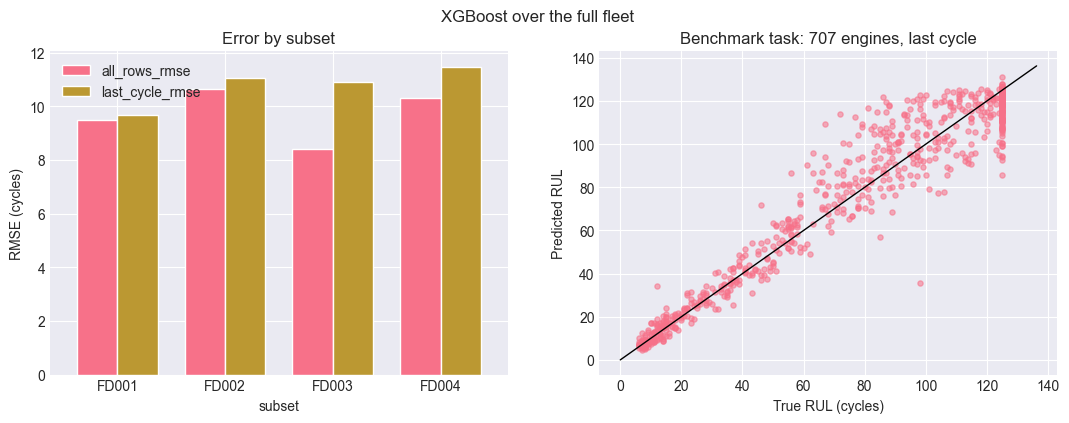

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
per_subset[['all_rows_rmse', 'last_cycle_rmse']].plot(kind='bar', ax=axes[0],
                                                      edgecolor='white', width=0.75)
axes[0].set_ylabel('RMSE (cycles)')
axes[0].set_title('Error by subset')
axes[0].tick_params(axis='x', rotation=0)

axes[1].scatter(y_test[last], pred_xgb[last], s=14, alpha=0.55)
lims = [0, max(y_test[last].max(), pred_xgb[last].max()) + 5]
axes[1].plot(lims, lims, linewidth=1, color='black')
axes[1].set_xlabel('True RUL (cycles)')
axes[1].set_ylabel('Predicted RUL')
axes[1].set_title(f'Benchmark task: {int(last.sum())} engines, last cycle')
fig.suptitle('XGBoost over the full fleet')
save_figure(fig, 'cmapss_model_fleet_performance', subfolder=ASSETS)
plt.show()

## 7. Which features the model actually uses

  ✓ Saved → assets\timeseries\cmapss_model_feature_importance.png


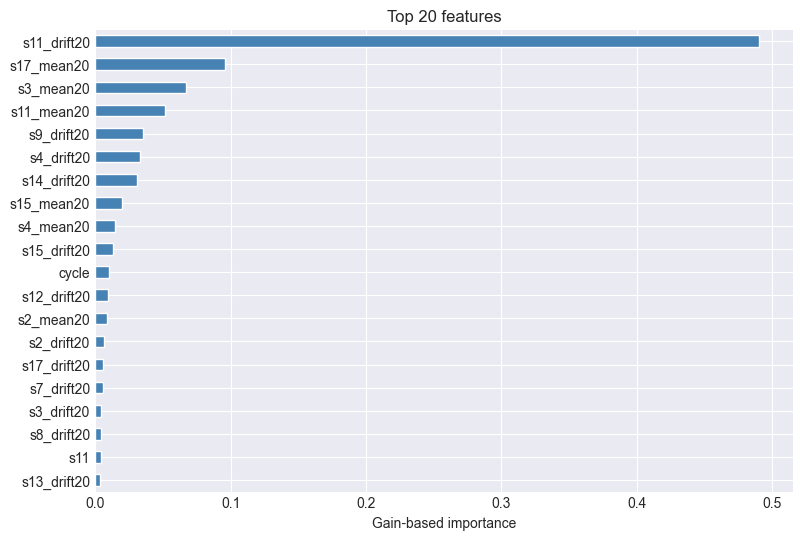

share of total importance
  raw sensor         2.6%
  cycle / regime     1.2%
  temporal          96.2%


In [10]:
importance = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
top = importance.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Gain-based importance')
ax.set_title('Top 20 features')
save_figure(fig, 'cmapss_model_feature_importance', subfolder=ASSETS)
plt.show()

kinds = {'raw sensor': 0.0, 'cycle / regime': 0.0, 'temporal': 0.0}
for name, value in importance.items():
    if name in ('cycle', 'regime_code'):
        kinds['cycle / regime'] += value
    elif name.endswith(('mean20', 'std20', 'drift20')):
        kinds['temporal'] += value
    else:
        kinds['raw sensor'] += value
print('share of total importance')
for k, v in kinds.items():
    print(f'  {k:<16} {v:6.1%}')

## 8. Log the run

The MLflow database in this repository held two runs, both from the FD001
notebook. This adds the fleet run beside them, so the tracking store and the
model card stop disagreeing about which model this project ships.

In [11]:
with mlflow.start_run(run_name='xgboost_full_fleet_notebook'):
    mlflow.log_params({**XGB_PARAMS,
                       'subsets': 'FD001+FD002+FD003+FD004',
                       'features': len(feature_cols),
                       'train_rows': len(train),
                       'rul_cap': prep['rul_cap']})
    mlflow.log_metrics({
        'rmse_all_rows': results['xgboost']['all_rows']['rmse'],
        'mae_all_rows': results['xgboost']['all_rows']['mae'],
        'r2_all_rows': results['xgboost']['all_rows']['r2'],
        'rmse_last_cycle': results['xgboost']['last_cycle']['rmse'],
        'mae_last_cycle': results['xgboost']['last_cycle']['mae'],
        'r2_last_cycle': results['xgboost']['last_cycle']['r2'],
        'train_seconds': xgb_time,
    })
    run_id = mlflow.active_run().info.run_id

print('logged run', run_id)

logged run 73135388d241474089d0b84cd4b88f3e


## 9. Does this reproduce the deployed model

`cmapss_full_fleet_meta.json` was written by the training script on 2026-08-30
and is what the model card and the project charter quote. Nothing above was
imported from that script. A difference here is worth more than an agreement: it
would mean the deployed number cannot be reproduced from the repository.

In [12]:
meta_path = CKPT_DIR / 'cmapss_full_fleet_meta.json'
meta = json.loads(meta_path.read_text(encoding='utf-8'))

print(f'{"model":<20}{"view":<12}{"here":>10}{"deployed":>11}{"delta":>10}')
print('-' * 63)
for model in ('linear_regression', 'xgboost'):
    for view in ('all_rows', 'last_cycle'):
        mine = results[model][view]['rmse']
        theirs = meta['results'][model][view]['rmse']
        print(f'{model:<20}{view:<12}{mine:>10.3f}{theirs:>11.3f}{mine - theirs:>+10.3f}')

model               view              here   deployed     delta
---------------------------------------------------------------
linear_regression   all_rows        14.356     14.356    +0.000
linear_regression   last_cycle      16.411     16.411    -0.000
xgboost             all_rows        10.051     10.051    +0.000
xgboost             last_cycle      11.012     11.012    +0.000


## 10. Results

| Model | All rows, RMSE | Benchmark task, 707 engines |
|---|---|---|
| Linear regression, same 70 features | 14.36 | 16.41 |
| XGBoost, deployed configuration | **10.05** | **11.01** |

Section 9 is the point of this notebook: every one of those four numbers matches
the deployed metrics file to three decimals, and nothing was imported from the
script that produced it. Two more results are worth carrying out of here:

- **The temporal features hold 96 per cent of the model's importance.** The raw
  sensor readings hold 2.6 per cent and the cycle counter with the regime code
  hold 1.2. That is the difference between a time-series module and tabular
  regression on time-indexed rows.
- **The linear baseline on those same features reaches 16.41.** A boosted model
  without them reaches 18.42, measured in the training script's feature ablation.
  A linear model with the right representation beats a non-linear one without it,
  which puts the credit where it belongs.

**Superseded:** the FD001 run of 2026-08-11, RMSE 17.11, whose model file is kept
at `models/01_cmapss/cmapss_xgb_FD001.pkl` as the comparison point.

**Next step:** `events/make_events_cmapss.py` turns these predictions into Arkon
risk events, and the n8n Quality Steering Cell turns those into incidents.